# 03 - DroneDetect V2 benchmark: per-drone one-vs-rest AUC

**Question:** What one-vs-rest AUC per drone do our measured features achieve
on the DroneDetect CLEAN benchmark?

Dataset: DroneDetect V2 (Swinney & Woods, IEEE DataPort 2021,
doi:10.21227/5jjj-1m32, CC BY 4.0), CLEAN subset: 7 drones x 3 flight modes
nominal (Disco: ON/FY, no hover, fixed-wing; Phantom 4: ON/HO, since the
release ships PHA_FY as an empty directory), 5 files per populated
drone-mode, each a 2 s / 60 Msps complex float32 recording at 2.4375 GHz
center.

No background/no-UAS class exists in the published dataset, so detection is
framed as 7-class drone identification with one-vs-rest ROC per drone. These
numbers are not directly comparable to Swinney & Woods' 8-class results
(they add a No-UAS class and evaluate under interference). See
docs/dronedetect_benchmark_report.md for methodology and caveats.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tacet.dsp import features
from tacet.loaders import cf32, dronedetect

In [2]:
# --- Configuration ---
DATASET_ROOT = Path("data/datasets/dronedetect_v2/CLEAN")
SYNTHETIC_FALLBACK = True  # demo pipeline on synthetic features when dataset absent
NFFT = 2048                # 29.3 kHz bins at 60 Msps; 28 MHz spans ~956 bins
WINDOW_S = 0.1             # 100 ms analysis windows
WINDOWS_PER_FILE = 10      # evenly spaced across the first 2.0 s
TRAIN_FILE_NOS = (0, 1, 2) # split by file -> no window leakage
TEST_FILE_NOS = (3, 4)
SEED = 20260922
LR_ITERS = 2000
LR_LR = 0.1
OBW_PERCENT = 99.0
DUTY_THRESHOLD_DB = -35.0
print("config ok")

config ok


In [3]:
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


def softmax_regression_train(X, y, n_classes, iters=LR_ITERS, lr=LR_LR):
    """Full-batch gradient-descent multinomial logistic regression.

    X: (n, d) standardized float64; y: (n,) int labels in [0, n_classes).
    Returns (W, b) with W (d, n_classes), b (n_classes,).
    """
    n, d = X.shape
    W = np.zeros((d, n_classes))
    b = np.zeros(n_classes)
    Y = np.eye(n_classes)[y]
    for _ in range(iters):
        P = softmax(X @ W + b)
        G = P - Y
        W -= lr * (X.T @ G) / n
        b -= lr * G.mean(axis=0)
    return W, b


def predict_proba(X, W, b):
    return softmax(X @ W + b)


def roc_curve_ovr(y_bin, scores):
    """One-vs-rest ROC points; ties handled at distinct-score boundaries."""
    order = np.argsort(-scores, kind="stable")
    y_s = y_bin[order]
    s_s = scores[order]
    n_pos = y_bin.sum()
    n_neg = len(y_bin) - n_pos
    tp = np.cumsum(y_s)
    fp = np.cumsum(1 - y_s)
    distinct = np.r_[s_s[1:] != s_s[:-1], True]
    tpr = np.r_[0.0, tp[distinct] / n_pos]
    fpr = np.r_[0.0, fp[distinct] / n_neg]
    return fpr, tpr


def auc_from_roc(fpr, tpr):
    return float(np.trapezoid(tpr, fpr))

In [4]:
# Classifier sanity check on synthetic separable data: guards the hand-rolled
# numpy softmax regression + ROC/AUC (notebook-only, not unit-tested).
rng = np.random.default_rng(SEED)
Xa = rng.standard_normal((300, 2)) * 0.5
Xb = rng.standard_normal((300, 2)) * 0.5 + 3.0
Xs = np.vstack([Xa, Xb])
ys = np.r_[np.zeros(300, dtype=int), np.ones(300, dtype=int)]
W, b = softmax_regression_train(Xs, ys, n_classes=2)
acc = (predict_proba(Xs, W, b).argmax(axis=1) == ys).mean()
scores_s = predict_proba(Xs, W, b)[:, 1]
fpr_s, tpr_s = roc_curve_ovr(ys == 1, scores_s)
auc_s = auc_from_roc(fpr_s, tpr_s)
print(f"sanity: accuracy={acc:.4f} AUC={auc_s:.4f}")
assert acc > 0.99 and auc_s > 0.99, "classifier/ROC sanity check failed"

sanity: accuracy=1.0000 AUC=1.0000


dataset present: True
AIR_0010_00.dat: 960000000 bytes = 120000000 complex samples (2.0000 s, nominal 2 s)
window stats: mean|z|=0.1397 p99.9|z|=1.4432


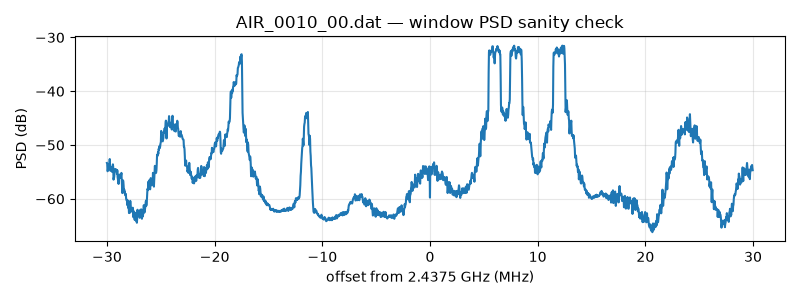

In [5]:
# Dataset sanity check: float32 little-endian reading is not officially
# documented — verify size % 8 == 0, plausible sample stats, visible PSD.
HAS_DATASET = DATASET_ROOT.is_dir() and any(DATASET_ROOT.glob("*/*.dat"))
print(f"dataset present: {HAS_DATASET}")
if HAS_DATASET:
    first = next(iter(sorted(DATASET_ROOT.glob("*/*.dat"))))
    size = first.stat().st_size
    n_avail = size // 8
    assert size % 8 == 0, f"file size {size} not a multiple of 8 bytes"
    z0 = cf32.load_cf32(str(first), n_samples=int(0.05 * dronedetect.SAMPLE_RATE_SPS))
    print(f"{first.name}: {size} bytes = {n_avail} complex samples "
          f"({n_avail / dronedetect.SAMPLE_RATE_SPS:.4f} s, nominal 2 s)")
    print(f"window stats: mean|z|={np.abs(z0).mean():.4f} "
          f"p99.9|z|={np.quantile(np.abs(z0), 0.999):.4f}")
    z0 = features.remove_dc(z0)
    f0, p0 = features.welch_psd(z0, dronedetect.SAMPLE_RATE_SPS, nfft=NFFT)
    plt.figure(figsize=(8, 3))
    plt.plot(f0 / 1e6, 10 * np.log10(p0 + 1e-30))
    plt.xlabel("offset from 2.4375 GHz (MHz)")
    plt.ylabel("PSD (dB)")
    plt.title(f"{first.name} — window PSD sanity check")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [6]:
# Index the dataset: per-file provenance + counts per drone/mode.
counts = None
if HAS_DATASET:
    dataset_files = dronedetect.list_dronedetect_files(str(DATASET_ROOT))
    print(f"{len(dataset_files)} files indexed; provenance: "
          f"{dataset_files[0]['source']} / doi:{dataset_files[0]['doi']} / "
          f"{dataset_files[0]['license']}")
    counts = (
        pd.DataFrame(dataset_files)
        .groupby(["drone", "model", "mode"])
        .size()
        .unstack(fill_value=0)
    )
counts

mode                   FY  HO  ON
drone model                      
AIR   DJI Air 2S        5   5   5
DIS   Parrot Disco      5   0   5
INS   DJI Inspire 2     5   5   5
MIN   DJI Mavic Mini    5   5   5
MP1   DJI Mavic Pro     5   5   5
MP2   DJI Mavic 2 Pro   5   5   5
PHA   DJI Phantom 4     0   5   5

95 files indexed; provenance: public_dataset / doi:10.21227/5jjj-1m32 / CC-BY-4.0


In [7]:
WINDOW_N = int(WINDOW_S * dronedetect.SAMPLE_RATE_SPS)


def window_features(path, start):
    """5-feature vector for one analysis window (existing tacet features)."""
    z = cf32.load_cf32(path, n_samples=WINDOW_N, start=start)
    z = features.remove_dc(z)
    fs = dronedetect.SAMPLE_RATE_SPS
    f, psd = features.welch_psd(z, fs, nfft=NFFT)
    obw_hz, _, _ = features.occupied_bandwidth(f, psd, percent=OBW_PERCENT)
    flat = features.spectral_flatness(psd)
    _, t, S = features.spectrogram(z, fs, nfft=NFFT, noverlap=NFFT // 2)
    env = features.time_envelope(S)
    duty = features.duty_cycle(env, threshold_rel_db=DUTY_THRESHOLD_DB)
    bursts = features.burst_structure(env, t, threshold_rel_db=DUTY_THRESHOLD_DB)
    del S
    return {
        "obw_hz": float(obw_hz),
        "spectral_flatness": float(flat),
        "duty_cycle": float(duty),
        "mean_burst_s": float(bursts["mean_burst_s"]),
        "mean_gap_s": float(bursts["mean_gap_s"]),
    }


def file_windows(meta):
    """Deterministic evenly-spaced windows across the first 2 s of a file."""
    n_avail = min(
        int(2.0 * dronedetect.SAMPLE_RATE_SPS),
        Path(meta["path"]).stat().st_size // 8,
    )
    if n_avail < WINDOW_N:
        raise ValueError(f"{meta['path']}: too short for one window")
    offsets = np.linspace(0, n_avail - WINDOW_N, WINDOWS_PER_FILE, dtype=int)
    for w_idx, off in enumerate(offsets):
        row = {
            "drone": meta["drone"],
            "model": meta["model"],
            "mode": meta["mode"],
            "file_num": meta["file_num"],
            "window_idx": w_idx,
        }
        row.update(window_features(meta["path"], int(off)))
        yield row

In [8]:
# Smoke pass: 1 file per (drone, mode) class through the whole path.
smoke_summary = None
if HAS_DATASET:
    smoke = dronedetect.sample_files(dataset_files, n_per_class=1, seed=SEED)
    smoke_rows = [r for m in smoke for r in file_windows(m)]
    smoke_df = pd.DataFrame(smoke_rows)
    print(f"smoke pass: {len(smoke)} files -> {len(smoke_df)} windows")
    smoke_summary = smoke_df.groupby("drone").mean(numeric_only=True)
smoke_summary

       file_num  window_idx        obw_hz  ...  duty_cycle  mean_burst_s  mean_gap_s
drone                                      ...                                      
AIR    2.000000         4.5  1.832617e+07  ...    0.077108      0.000266    0.003113
DIS    2.000000         4.5  2.340674e+07  ...    0.124445      0.000434    0.003147
INS    2.666667         4.5  2.975977e+07  ...    0.414328      0.004478    0.002181
MIN    2.333333         4.5  1.604297e+07  ...    0.222590      0.000131    0.000537
MP1    1.333333         4.5  3.055957e+07  ...    0.355002      0.000514    0.001178
MP2    2.666667         4.5  4.021582e+07  ...    0.621020      0.014449    0.001225
PHA    3.500000         4.5  2.724023e+07  ...    0.497252      0.001926    0.002170

[7 rows x 7 columns]

smoke pass: 19 files -> 190 windows


In [9]:
# Full feature extraction over all indexed files (~10-20 min; progress below).
if HAS_DATASET:
    import time

    rows = []
    t0 = time.time()
    for i, meta in enumerate(dataset_files, 1):
        rows.extend(file_windows(meta))
        print(
            f"[{i:2d}/{len(dataset_files)}] {meta['drone']}_{meta['mode']} "
            f"file {meta['file_num']} ({time.time() - t0:.0f} s)",
            flush=True,
        )
    feat_df = pd.DataFrame(rows)
    print(f"feature table: {len(feat_df)} windows x {len(feat_df.columns)} cols")

[ 1/95] AIR_FY file 0 (15 s)
[ 2/95] AIR_FY file 1 (29 s)
[ 3/95] AIR_FY file 2 (44 s)
[ 4/95] AIR_FY file 3 (57 s)
[ 5/95] AIR_FY file 4 (71 s)
[ 6/95] AIR_HO file 0 (85 s)
[ 7/95] AIR_HO file 1 (100 s)
[ 8/95] AIR_HO file 2 (115 s)
[ 9/95] AIR_HO file 3 (128 s)
[10/95] AIR_HO file 4 (142 s)
[11/95] AIR_ON file 0 (155 s)
[12/95] AIR_ON file 1 (170 s)
[13/95] AIR_ON file 2 (184 s)
[14/95] AIR_ON file 3 (199 s)
[15/95] AIR_ON file 4 (213 s)
[16/95] DIS_FY file 0 (228 s)
[17/95] DIS_FY file 1 (243 s)
[18/95] DIS_FY file 2 (255 s)
[19/95] DIS_FY file 3 (270 s)
[20/95] DIS_FY file 4 (284 s)
[21/95] DIS_ON file 0 (299 s)
[22/95] DIS_ON file 1 (314 s)
[23/95] DIS_ON file 2 (328 s)
[24/95] DIS_ON file 3 (342 s)
[25/95] DIS_ON file 4 (356 s)
[26/95] INS_FY file 0 (370 s)
[27/95] INS_FY file 1 (385 s)
[28/95] INS_FY file 2 (400 s)
[29/95] INS_FY file 3 (413 s)
[30/95] INS_FY file 4 (427 s)
[31/95] INS_HO file 0 (441 s)
[32/95] INS_HO file 1 (456 s)
[33/95] INS_HO file 2 (471 s)
[34/95] INS_HO f

In [10]:
# SYNTHETIC FALLBACK — pipeline demo only, not measurements.
if not HAS_DATASET and SYNTHETIC_FALLBACK:
    print("SYNTHETIC FALLBACK: dataset absent — demo on synthetic features")
    rng = np.random.default_rng(SEED)
    rows = []
    for d in sorted(dronedetect.DRONE_MODELS):
        base = rng.uniform(size=5)
        for mode in ("ON", "HO", "FY"):
            for file_num in range(5):
                for w in range(WINDOWS_PER_FILE):
                    sig = np.clip(base + rng.normal(scale=0.05, size=5), 0.02, None)
                    rows.append(
                        {
                            "drone": d,
                            "model": dronedetect.DRONE_MODELS[d],
                            "mode": mode,
                            "file_num": file_num,
                            "window_idx": w,
                            "obw_hz": sig[0] * 20e6,
                            "spectral_flatness": sig[1] * 0.5,
                            "duty_cycle": sig[2],
                            "mean_burst_s": sig[3] * 1e-3,
                            "mean_gap_s": sig[4] * 1e-3,
                        }
                    )
    feat_df = pd.DataFrame(rows)
    print(f"synthetic feature table: {len(feat_df)} windows")
feat_df.head()

  drone       model mode  ...  duty_cycle  mean_burst_s  mean_gap_s
0   AIR  DJI Air 2S   FY  ...    0.071355      0.000324    0.003879
1   AIR  DJI Air 2S   FY  ...    0.045920      0.000255    0.004285
2   AIR  DJI Air 2S   FY  ...    0.080574      0.000269    0.003033
3   AIR  DJI Air 2S   FY  ...    0.067771      0.000323    0.004041
4   AIR  DJI Air 2S   FY  ...    0.062137      0.000270    0.004126

[5 rows x 10 columns]

In [11]:
# Split by FILE (never by window): files 00-02 train, 03-04 test.
FEATURE_COLS = [
    "obw_hz",
    "spectral_flatness",
    "duty_cycle",
    "mean_burst_s",
    "mean_gap_s",
]
label_codes = sorted(feat_df["drone"].unique())
label_map = {c: i for i, c in enumerate(label_codes)}

is_train = feat_df["file_num"].isin(TRAIN_FILE_NOS)
train_df = feat_df[is_train].reset_index(drop=True)
test_df = feat_df[~is_train].reset_index(drop=True)
print(f"train windows {len(train_df)} / test windows {len(test_df)}")
assert (
    set(train_df["drone"]) == set(test_df["drone"]) == set(label_codes)
), "each drone must appear in both splits (3 train / 2 test files)"

X_tr = train_df[FEATURE_COLS].to_numpy(dtype=np.float64)
X_te = test_df[FEATURE_COLS].to_numpy(dtype=np.float64)
mu, sd = X_tr.mean(axis=0), X_tr.std(axis=0)
sd = np.where(sd > 0, sd, 1.0)  # guard constant columns
X_tr_z = (X_tr - mu) / sd
X_te_z = (X_te - mu) / sd
y_tr = train_df["drone"].map(label_map).to_numpy()
y_te = test_df["drone"].map(label_map).to_numpy()

W, b = softmax_regression_train(X_tr_z, y_tr, n_classes=len(label_codes))
proba_te = predict_proba(X_te_z, W, b)
pred_te = proba_te.argmax(axis=1)
print(f"test accuracy: {(pred_te == y_te).mean():.4f}")

train windows 570 / test windows 380
test accuracy: 0.4211


In [12]:
# Per-drone feature means over all 950 windows: the evidence behind the
# report's reading of MIN's separability (burst timing + narrow OBW).
feat_df.groupby("drone")[FEATURE_COLS].mean()

             obw_hz  spectral_flatness  duty_cycle  mean_burst_s  mean_gap_s
drone                                                                       
AIR    2.893301e+07           0.040190    0.117967      0.000231    0.002698
DIS    2.995518e+07           0.097683    0.127467      0.001340    0.002470
INS    3.170293e+07           0.086070    0.373125      0.001812    0.003044
MIN    1.553555e+07           0.022282    0.248099      0.000141    0.000559
MP1    3.262598e+07           0.081906    0.395167      0.002540    0.001005
MP2    3.514043e+07           0.098575    0.418621      0.003291    0.001391
PHA    2.898750e+07           0.037016    0.445526      0.001586    0.002377

In [13]:
# Per-drone one-vs-rest ROC + AUC (score = softmax P(drone)).
results = []
roc_curves = {}
for code, idx in sorted(label_map.items()):
    y_bin = y_te == idx
    scores = proba_te[:, idx]
    fpr, tpr = roc_curve_ovr(y_bin, scores)
    roc_curves[code] = (fpr, tpr)
    results.append(
        {
            "drone": code,
            "model": dronedetect.DRONE_MODELS[code],
            "n_test_windows": int(y_bin.sum()),
            "auc": auc_from_roc(fpr, tpr),
        }
    )
auc_df = pd.DataFrame(results).set_index("drone")
auc_df

                 model  n_test_windows       auc
drone                                           
AIR         DJI Air 2S              60  0.740521
DIS       Parrot Disco              40  0.843529
INS      DJI Inspire 2              60  0.729688
MIN     DJI Mavic Mini              60  0.978021
MP1      DJI Mavic Pro              60  0.788490
MP2    DJI Mavic 2 Pro              60  0.601823
PHA      DJI Phantom 4              40  0.884191

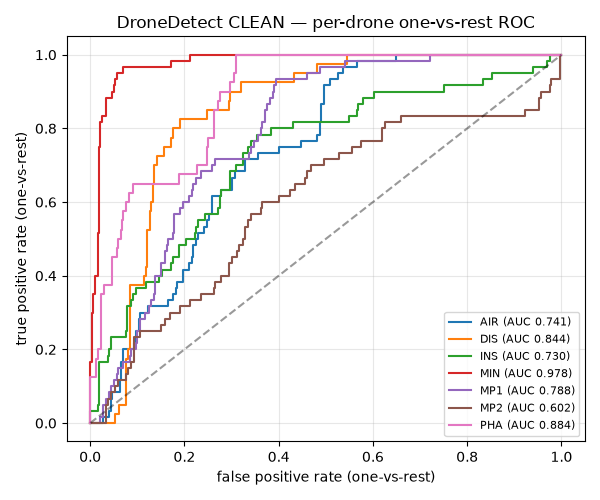

In [14]:
title_suffix = " (SYNTHETIC)" if not HAS_DATASET else ""
plt.figure(figsize=(6, 5))
for code, (fpr, tpr) in sorted(roc_curves.items()):
    plt.plot(fpr, tpr, label=f"{code} (AUC {auc_df.loc[code, 'auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("false positive rate (one-vs-rest)")
plt.ylabel("true positive rate (one-vs-rest)")
plt.title(f"DroneDetect CLEAN — per-drone one-vs-rest ROC{title_suffix}")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Per-mode AUC breakdown: positives = (drone, mode) test windows, negatives =
# all other drones' test windows. 2 test files (20 windows) per cell: noisy.
mode_rows = []
for (code, mode), grp in test_df.groupby(["drone", "mode"]):
    others = test_df.index[test_df["drone"] != code].to_numpy()
    scores = np.r_[
        proba_te[grp.index.to_numpy(), label_map[code]],
        proba_te[others, label_map[code]],
    ]
    y_bin = np.r_[
        np.ones(len(grp), dtype=bool),
        np.zeros(len(others), dtype=bool),
    ]
    fpr, tpr = roc_curve_ovr(y_bin, scores)
    mode_rows.append(
        {"drone": code, "mode": mode, "n_pos": len(grp),
         "auc": auc_from_roc(fpr, tpr)}
    )
mode_df = pd.DataFrame(mode_rows).pivot(
    index="drone", columns="mode", values="auc"
)
mode_df

mode         FY        HO        ON
drone                              
AIR    0.827812  0.816562  0.577187
DIS    0.813676       NaN  0.873382
INS    0.644375  0.741094  0.803594
MIN    0.967656  0.985469  0.980938
MP1    0.718906  0.809375  0.837187
MP2    0.333750  0.609219  0.862500
PHA         NaN  0.797206  0.971176

In [16]:
# Confusion matrix (rows = true, columns = predicted).
conf = pd.DataFrame(0, index=label_codes, columns=label_codes)
for true, pred in zip(y_te, pred_te):
    conf.iloc[true, pred] += 1
conf

     AIR  DIS  INS  MIN  MP1  MP2  PHA
AIR   19   23    0    7    2    9    0
DIS    2   13   12    5    8    0    0
INS   13    4   19    6    4    8    6
MIN    0    0    0   57    1    2    0
MP1   17    0    0    1   30   12    0
MP2   21    1   10    1   17   10    0
PHA   14    0    9    0    2    3   12

## Honest-results note

- CLEAN subset only; no background/no-UAS class exists in the published
  DroneDetect V2, so this is 7-class drone identification framed as
  one-vs-rest detection, not comparable to Swinney & Woods' 8-class 98.1%
  (they add a No-UAS class and evaluate under interference).
- Unit of evaluation is a 100 ms window, not a file or a track; windows from
  the same recording are correlated. The split is by file (00-02 train /
  03-04 test) so no window from a test file is seen in training.
- Per-mode cells rest on 2 test files (20 windows) per drone-mode: noisy,
  read as indicative only.
- Features were designed for bench ELRS/O4 characterization and are applied
  cross-dataset here; rail_fraction is excluded (int8 rails do not apply to
  float32 data).
- If the cell outputs above are labeled SYNTHETIC, the dataset was absent
  and the run demonstrates the pipeline only, not measurements.

## Dataset citation

Swinney, C.J.; Woods, J.C., "DroneDetect Dataset: A Radio Frequency dataset
of UAS Signals for Machine Learning Detection & Classification," IEEE
DataPort, June 12, 2021, doi:10.21227/5jjj-1m32. Licensed CC BY 4.0.
Reference results: Swinney & Woods, Aerospace 2021, 8(7):179,
doi:10.3390/aerospace8070179.